# **Reduction**(Master Bias and Master Flats)

---



# Imports

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from astropy.io import fits
import os

# Create master bias

In [2]:
bias_dir = "./bias/" # Folder with all the bias
bias_files = []
# List all the bias files in the directory
for file in os.listdir(bias_dir):
    if file.endswith(".fits"):
        bias_files += [file]


# Load the Bias Images
bias_images = []
for file in bias_files:
    image = fits.getdata(bias_dir+file)
    bias_images.append(image)

# Stack the Bias images using median
master_bias = np.median(np.asarray(bias_images), axis=0)


# Save the master bias as a FITS file(in the working directory)

In [3]:
savename=bias_dir+"master_bias.fits"
fits.writeto(savename, master_bias, overwrite=True)

# Create Master Flat

In [8]:
# Create master flat
flat_dir = "./flats/" # Folder with all the flats
flat_files = []
# List all the flat files in the directory
#make one master flat per filter

for dirs in os.listdir(flat_dir):
    for file in os.listdir(flat_dir+dirs):
        if file.endswith(".fits"):
            flat_files += [(file, dirs)]
print(flat_files)

#per filter
for filter in os.listdir(flat_dir):
    flat_images = []
    for file, filt in flat_files:
        if filt == filter:
            image = fits.getdata(flat_dir+filt+"/"+file)
            flat_images.append(image - master_bias) # Subtract the master bias
    # Stack the Flat images using median
    master_flat = np.median(np.asarray(flat_images), axis=0)
    # Normalize the master flat
    master_flat = master_flat / np.median(master_flat)
    savename=flat_dir+filter+"/master_flat_"+filter+".fits"

    fits.writeto(savename, master_flat, overwrite=True)

    #
# Load the Flat Images
# flat_images = []
# for file, dirs in flat_files:
#     image = fits.getdata(flat_dir+dirs+'/'+file)
#     flat_images.append(image)

# Stack the flat images

# cflats = []
# for ic in range(len(flat_images)):
#     cflats.append((flat_images[ic] - master_bias)/np.median(flat_images[ic]-master_bias))
# master_flat = np.median(cflats,axis=0)


[('Flat_2025-09-12_18-53-50_black_0036.fits', 'black'), ('Flat_2025-09-12_18-54-41_black_0037.fits', 'black'), ('Flat_2025-09-12_18-54-44_black_0038.fits', 'black'), ('Flat_2025-09-12_18-54-47_black_0039.fits', 'black'), ('Flat_2025-09-12_18-54-50_black_0040.fits', 'black'), ('Flat_2025-09-12_18-54-53_black_0041.fits', 'black'), ('Flat_2025-09-12_18-54-56_black_0042.fits', 'black'), ('Flat_2025-09-12_18-54-59_black_0043.fits', 'black'), ('Flat_2025-09-12_18-55-02_black_0044.fits', 'black'), ('Flat_2025-09-12_18-55-04_black_0045.fits', 'black'), ('Flat_2025-09-12_18-46-57_Blue_0003.fits', 'blue'), ('Flat_2025-09-12_18-47-01_Blue_0004.fits', 'blue'), ('Flat_2025-09-12_18-47-04_Blue_0005.fits', 'blue'), ('Flat_2025-09-12_18-47-08_Blue_0006.fits', 'blue'), ('Flat_2025-09-12_18-47-12_Blue_0007.fits', 'blue'), ('Flat_2025-09-12_18-47-15_Blue_0008.fits', 'blue'), ('Flat_2025-09-12_18-47-19_Blue_0009.fits', 'blue'), ('Flat_2025-09-12_18-47-23_Blue_0010.fits', 'blue'), ('Flat_2025-09-12_18-47-2

# Save the master flat as a FITS file

In [ ]:
#fits.writeto(flat_dir+"master_flat.fits", master_flat, overwrite=True)

# Plot both

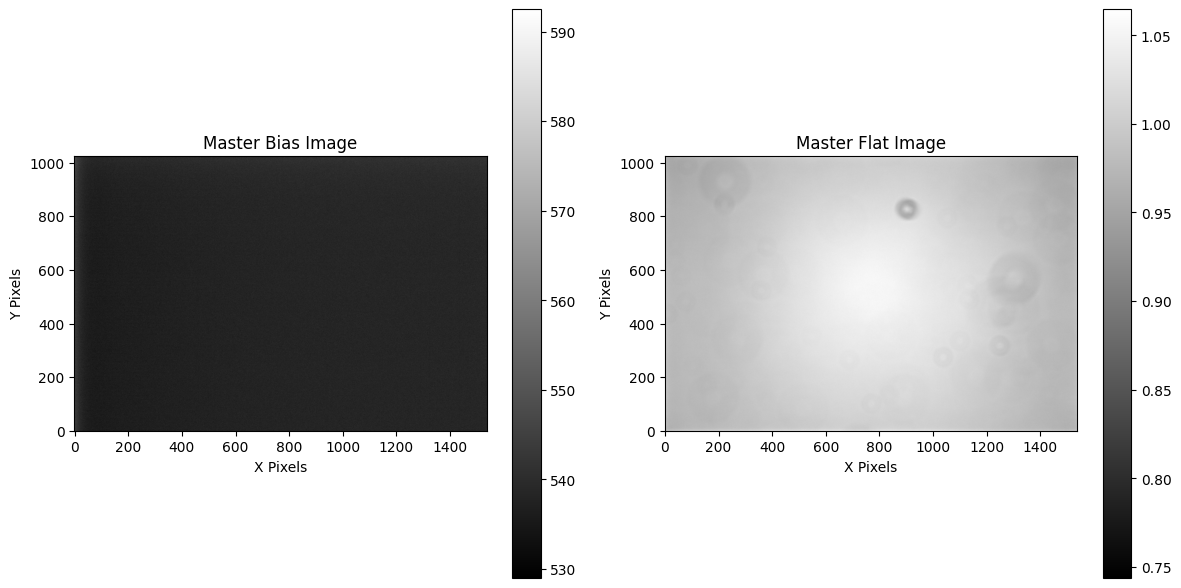

In [9]:
# Create a single figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))  # 1 row, 2 columns of subplots

# Plot the master bias in the first subplot
im1 = ax1.imshow(master_bias, cmap='gray', origin='lower')
ax1.set_title('Master Bias Image')
ax1.set_xlabel('X Pixels')
ax1.set_ylabel('Y Pixels')
fig.colorbar(im1, ax=ax1)  # Use fig.colorbar with the corresponding axis

# Plot the master flat in the second subplot
im2 = ax2.imshow(master_flat, cmap='gray', origin='lower')
ax2.set_title('Master Flat Image')
ax2.set_xlabel('X Pixels')
ax2.set_ylabel('Y Pixels')
fig.colorbar(im2, ax=ax2)  # Use fig.colorbar with the corresponding axis

plt.tight_layout()  # Ensure proper spacing between subplots
plt.show()